In [1]:
# EDA for Time Series Financial Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Load indexed CSVs
df_tsla = pd.read_csv("../data/processed/tsla_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_bnd  = pd.read_csv("../data/processed/bnd_cleaned.csv",  parse_dates=["Date"], index_col="Date")
df_spy  = pd.read_csv("../data/processed/spy_cleaned.csv",  parse_dates=["Date"], index_col="Date")

# ---- Check basic stats & types ----
print("TSLA dtypes and head:\n", df_tsla.dtypes, "\n")
print(df_tsla.head(), "\n")

print("Null counts:\n")
print(df_tsla.isna().sum(), "\n")

# ---- Descriptive summary statistics ----
print("Descriptive statistics (TSLA):")
print(df_tsla.describe(), "\n")


TSLA dtypes and head:
 Close     str
High      str
Low       str
Open      str
Volume    str
Ticker    str
dtype: object 

                         Close                High                 Low  \
Date                                                                     
NaT                       TSLA                TSLA                TSLA   
2015-01-02  14.620667457580566  14.883333206176758   14.21733283996582   
2015-01-05  14.005999565124512  14.433333396911621  13.810667037963867   
2015-01-06  14.085332870483398  14.279999732971191   13.61400032043457   
2015-01-07  14.063332557678223    14.3186674118042  13.985333442687988   

                          Open    Volume Ticker  
Date                                             
NaT                       TSLA      TSLA    NaN  
2015-01-02  14.857999801635742  71466000   TSLA  
2015-01-05  14.303333282470703  80527500   TSLA  
2015-01-06  14.003999710083008  93928500   TSLA  
2015-01-07  14.223333358764648  44526000   TSLA   

Null c

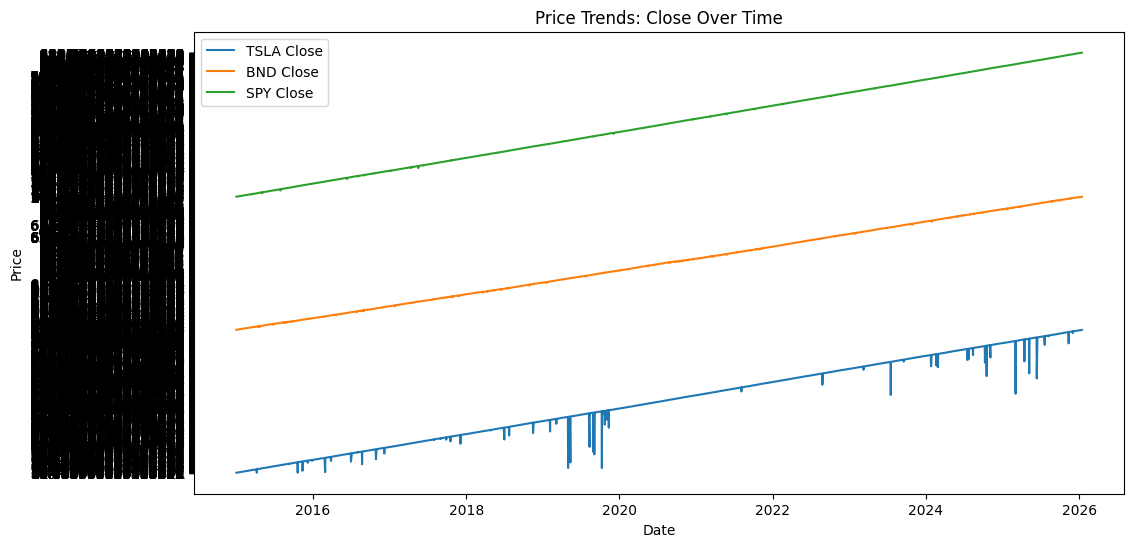

In [2]:
# Plot Close price over time
plt.figure(figsize=(12,6))
plt.plot(df_tsla["Close"], label="TSLA Close")
plt.plot(df_bnd["Close"], label="BND Close")
plt.plot(df_spy["Close"], label="SPY Close")
plt.title("Price Trends: Close Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


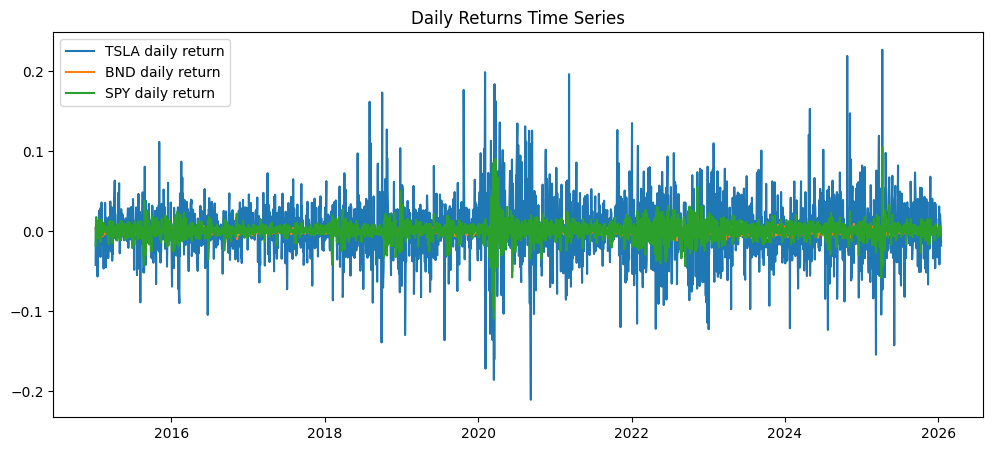

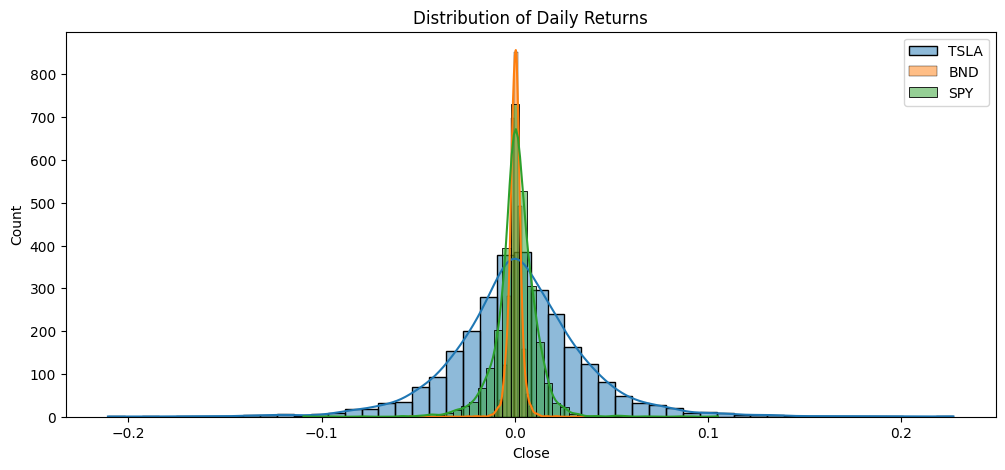

In [4]:


# --- Ensure numeric Close values ---
df_tsla["Close"] = pd.to_numeric(df_tsla["Close"], errors="coerce")
df_bnd["Close"]  = pd.to_numeric(df_bnd["Close"], errors="coerce")
df_spy["Close"]  = pd.to_numeric(df_spy["Close"], errors="coerce")

# --- Daily returns ---
rets_tsla = df_tsla["Close"].pct_change().dropna()
rets_bnd  = df_bnd["Close"].pct_change().dropna()
rets_spy  = df_spy["Close"].pct_change().dropna()

# --- Plot daily returns ---
plt.figure(figsize=(12,5))
plt.plot(rets_tsla, label="TSLA daily return")
plt.plot(rets_bnd,  label="BND daily return")
plt.plot(rets_spy,  label="SPY daily return")
plt.title("Daily Returns Time Series")
plt.legend()
plt.show()

# --- Histogram of returns (volatility) ---
plt.figure(figsize=(12,5))
sns.histplot(rets_tsla, bins=50, label="TSLA", kde=True)
sns.histplot(rets_bnd,  bins=50, label="BND",  kde=True)
sns.histplot(rets_spy,  bins=50, label="SPY",  kde=True)
plt.title("Distribution of Daily Returns")
plt.legend()
plt.show()


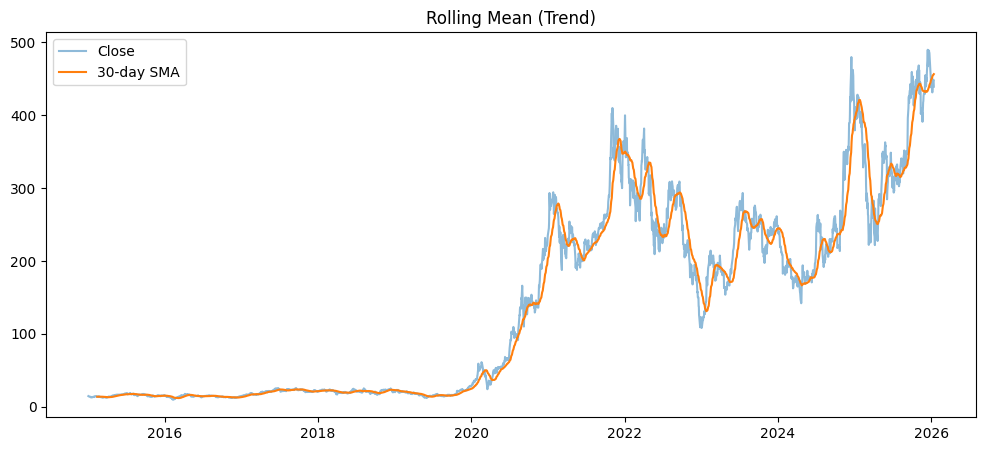

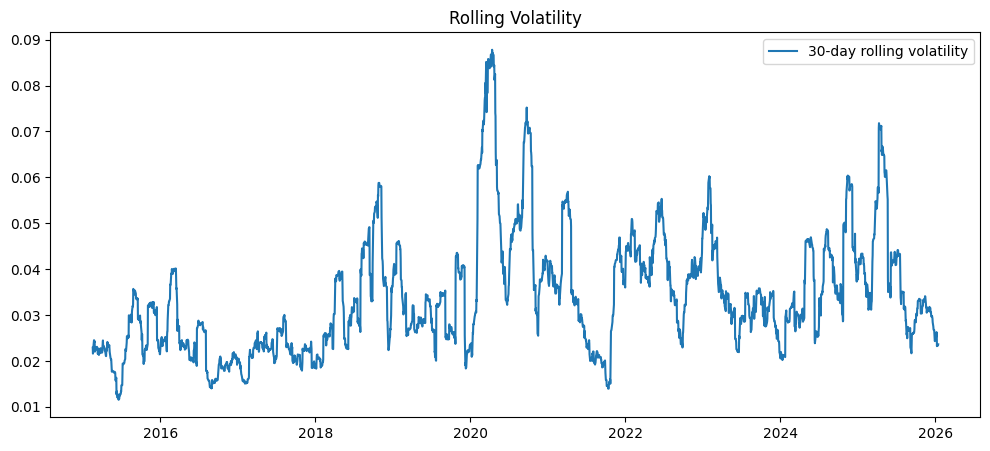

In [5]:
# 30-day rolling mean & volatility
window = 30

roll_mean = df_tsla["Close"].rolling(window).mean()
roll_vol  = df_tsla["Close"].pct_change().rolling(window).std()

plt.figure(figsize=(12,5))
plt.plot(df_tsla["Close"], alpha=0.5, label="Close")
plt.plot(roll_mean, label=f"{window}-day SMA")
plt.title("Rolling Mean (Trend)")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(roll_vol, label=f"{window}-day rolling volatility")
plt.title("Rolling Volatility")
plt.legend()
plt.show()


In [6]:
def run_adf(series, label):
    adf_res = adfuller(series.dropna())
    print(f"{label} ADF p-value: {adf_res[1]:.4f}")

run_adf(df_tsla["Close"], "TSLA Close")
run_adf(rets_tsla,        "TSLA Daily Returns")


TSLA Close ADF p-value: 0.8249
TSLA Daily Returns ADF p-value: 0.0000


In [7]:
# Value at Risk (VaR) at 5%
var_95 = rets_tsla.quantile(0.05)
print(f"TSLA 5% daily VaR: {var_95:.4f}")

# Sharpe Ratio
risk_free_rate = 0.04/252  # approx annual 4% -> daily
sharpe_tsla = (rets_tsla.mean() - risk_free_rate) / rets_tsla.std()
print(f"TSLA Sharpe Ratio: {sharpe_tsla:.4f}")


TSLA 5% daily VaR: -0.0525
TSLA Sharpe Ratio: 0.0475


In [8]:
# Identify extreme moves
threshold = 0.1  # ±10% day
outliers = rets_tsla[(rets_tsla > threshold) | (rets_tsla < -threshold)]
print("Days with >10% move:\n", outliers.sort_values())


Days with >10% move:
 Date
2020-09-08   -0.210628
2020-03-16   -0.185778
2020-02-05   -0.171758
2020-03-18   -0.160344
2025-03-10   -0.154262
2025-06-05   -0.142599
2018-09-28   -0.139015
2019-07-25   -0.136137
2020-03-09   -0.135725
2019-01-18   -0.129711
2020-02-27   -0.128146
2024-07-24   -0.123346
2023-01-03   -0.122422
2022-04-26   -0.121841
2024-01-25   -0.121253
2021-11-09   -0.119903
2020-03-12   -0.116172
2022-01-27   -0.115542
2022-12-27   -0.114089
2016-06-22   -0.104503
2025-04-04   -0.104198
2020-09-23   -0.103411
2020-05-01   -0.103034
2023-09-11    0.100925
2020-04-27    0.101496
2020-11-18    0.101968
2024-07-02    0.101973
2020-01-30    0.102962
2018-12-26    0.103930
2022-01-31    0.106776
2020-07-10    0.107848
2020-09-09    0.109233
2023-01-26    0.109673
2018-08-07    0.109886
2023-01-27    0.110002
2015-11-04    0.111735
2020-08-17    0.112031
2020-03-02    0.113220
2025-03-24    0.119336
2024-04-24    0.120611
2020-08-31    0.125689
2020-09-14    0.125832
2021-10